# 🏠 Boston Housing Price Prediction

A Machine Learning regression project predicting **median house prices** in Boston suburbs using multiple regression models.

**Models compared:**
- `LinearRegression` — baseline
- `RandomForestRegressor` — ensemble
- `GradientBoostingRegressor` ✅ Best

**Techniques:** EDA · Feature Engineering · Pipeline · GridSearchCV · RandomizedSearchCV · LazyPredict · Learning Curves

---
**Target variable:** `medv` — Median value of owner-occupied homes (in $1000s)

**Sections:**
1. Libraries
2. Load Data & EDA
3. Preprocessing Pipeline
4. Model Comparison — LazyPredict
5. Model Training & Evaluation
6. Hyperparameter Tuning
7. Learning Curves
8. Results Summary

## 1. Libraries

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn missingno ydata-profiling lazypredict xgboost lightgbm joblib -q

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from lazypredict.Supervised import LazyRegressor
import joblib

np.random.seed(42)
print('All libraries imported successfully.')

## 2. Load Data & EDA

In [8]:
# ── Load data ─────────────────────────────────────────────────────────────────
data = pd.read_csv("C:\\Users\\Dell\\Desktop\\AAA 2006\\2026 AI Total\\Boston housing\\BostonHousing.csv")
print(f'Shape: {data.shape}')
data.head()

Shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [9]:
# Basic info
print('Dataset Info:')
print('='*50)
data.info()
print('\nDescriptive Statistics:')
data.describe().round(2)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB

Descriptive Statistics:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.00,506.00,506.00,506.00,506.00,501.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.71,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.88,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


Missing values:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


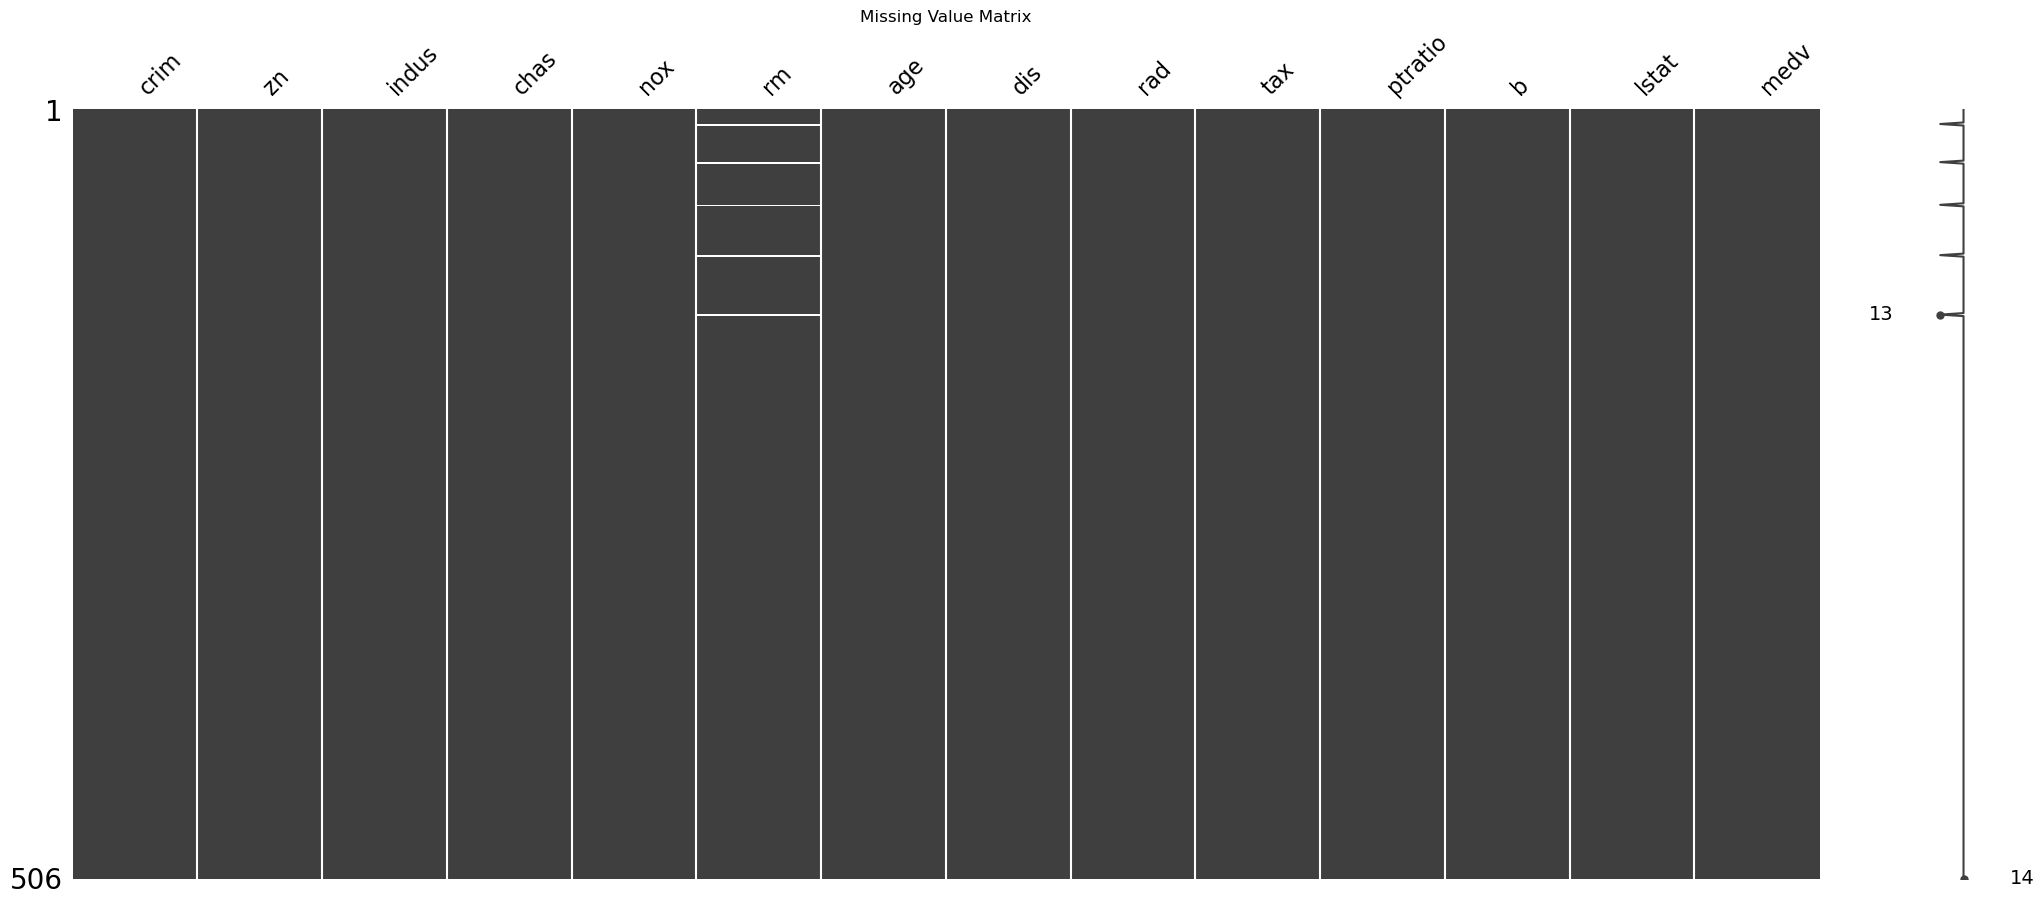

In [10]:
# Missing values
print('Missing values:')
print(data.isnull().sum())
msno.matrix(data)
plt.title('Missing Value Matrix')
plt.show()

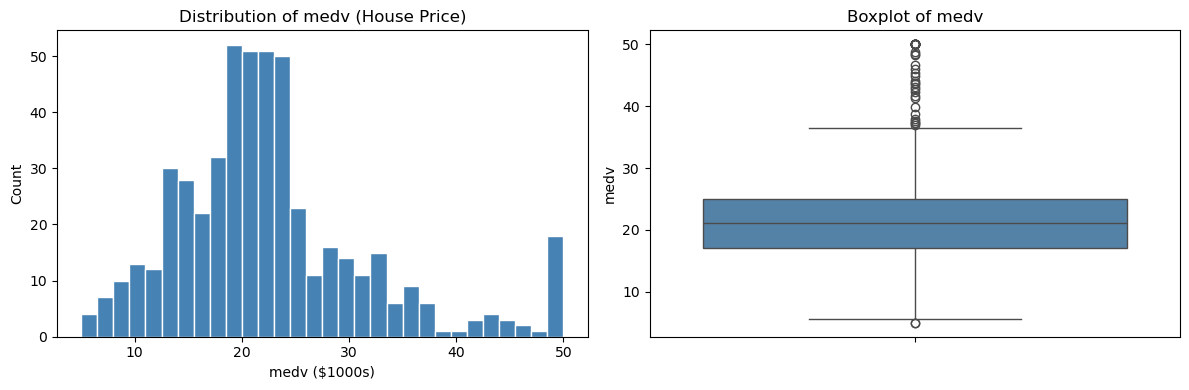

In [11]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data['medv'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of medv (House Price)')
axes[0].set_xlabel('medv ($1000s)')
axes[0].set_ylabel('Count')
sns.boxplot(y=data['medv'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot of medv')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

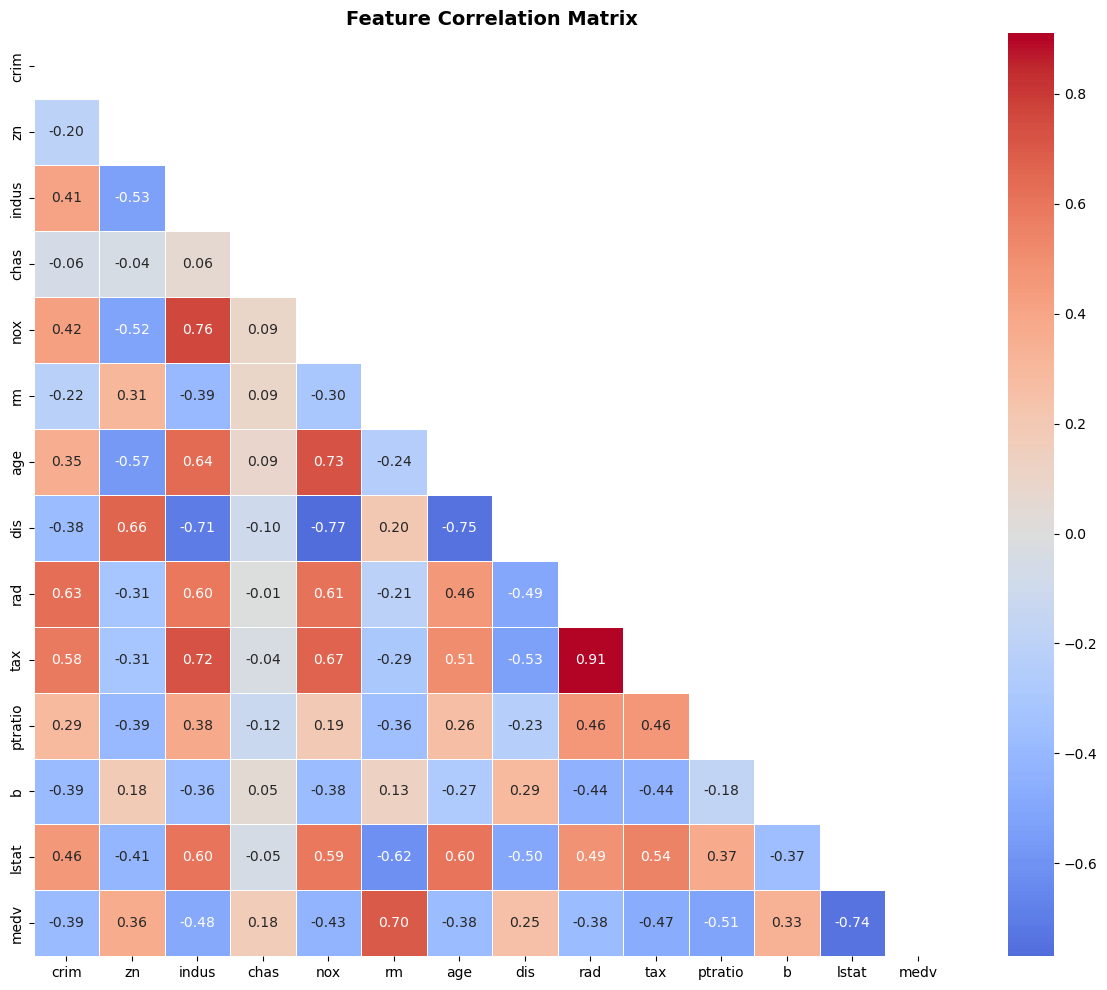

In [12]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

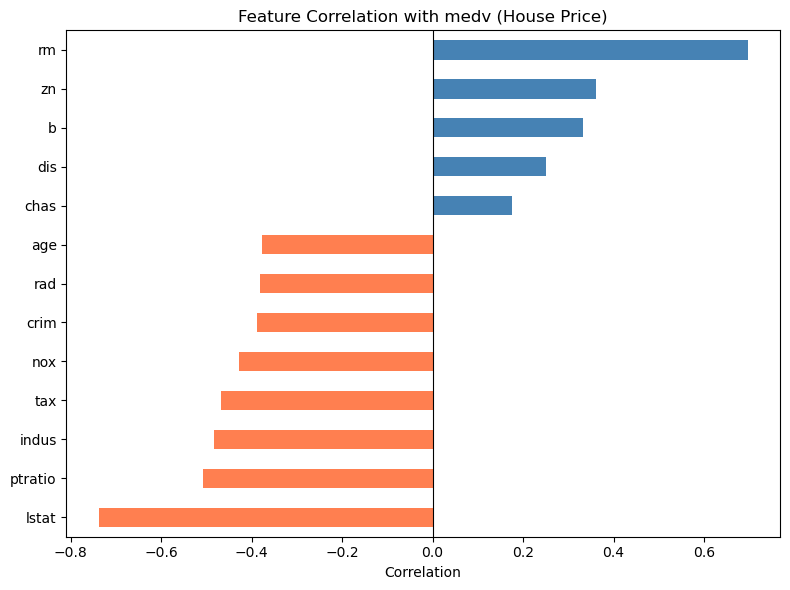

rm         0.696169
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64


In [13]:
# Top correlations with target
corr_target = data.corr()['medv'].drop('medv').sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
corr_target.plot(kind='barh', color=['coral' if v < 0 else 'steelblue' for v in corr_target], ax=ax)
ax.set_title('Feature Correlation with medv (House Price)')
ax.set_xlabel('Correlation')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150)
plt.show()
print(corr_target.sort_values(ascending=False))

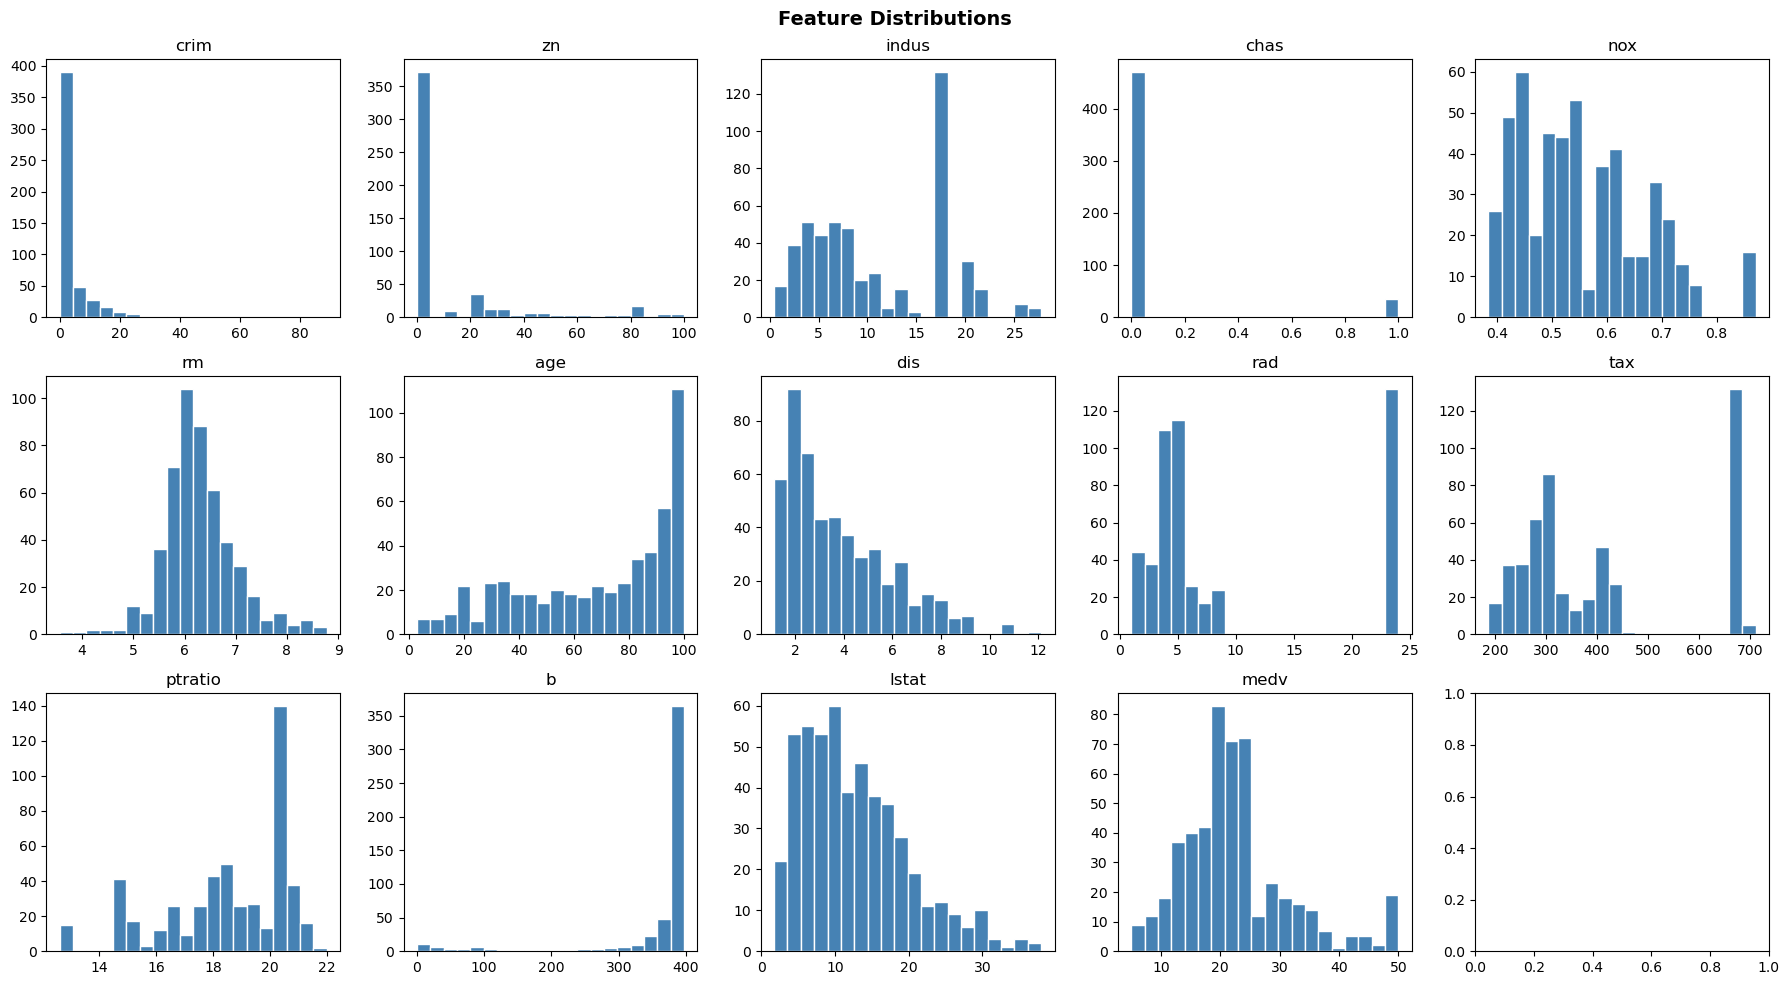

In [14]:
# Feature distributions
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
for i, col in enumerate(data.columns):
    ax = axes[i // 5][i % 5]
    ax.hist(data[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

## 3. Preprocessing Pipeline

In [15]:
# ── Train/Test Split ──────────────────────────────────────────────────────────
target = 'medv'
x = data.drop(target, axis=1)
y = data[target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f'Train: {x_train.shape} | Test: {x_test.shape}')

# ── Preprocessing pipeline ────────────────────────────────────────────────────
num_features = ['crim','zn','indus','nox','rm','age','dis','rad','tax','ptratio','b','lstat']
cat_features = ['chas']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

chas_cats = x_train['chas'].unique()
ord_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[chas_cats]))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', ord_transformer, cat_features),
])
print('Preprocessing pipeline defined.')

Train: (404, 13) | Test: (102, 13)
Preprocessing pipeline defined.


## 4. Model Comparison — LazyPredict

In [16]:
# Preprocess first for LazyPredict
x_train_proc = preprocessor.fit_transform(x_train)
x_test_proc  = preprocessor.transform(x_test)

reg = LazyRegressor(verbose=0, ignore_warnings=False, custom_metric=None)
models, predictions = reg.fit(x_train_proc, x_test_proc, y_train, y_test)
print('\nTop 10 Models:')
print(models.head(10))


Top 10 Models:
                               Adjusted R-Squared  R-Squared      RMSE  \
Model                                                                    
GradientBoostingRegressor                0.894440   0.908027  2.597061   
RandomForestRegressor                    0.873804   0.890047  2.839587   
LGBMRegressor                            0.865326   0.882660  2.933421   
XGBRegressor                             0.864537   0.881973  2.941998   
BaggingRegressor                         0.854844   0.873527  3.045445   
DecisionTreeRegressor                    0.853871   0.872680  3.055628   
HistGradientBoostingRegressor            0.848424   0.867934  3.112063   
ExtraTreesRegressor                      0.841820   0.862180  3.179132   
AdaBoostRegressor                        0.809225   0.833781  3.491346   
ExtraTreeRegressor                       0.741399   0.774685  4.064878   

                               Time Taken  
Model                                      
Gradien

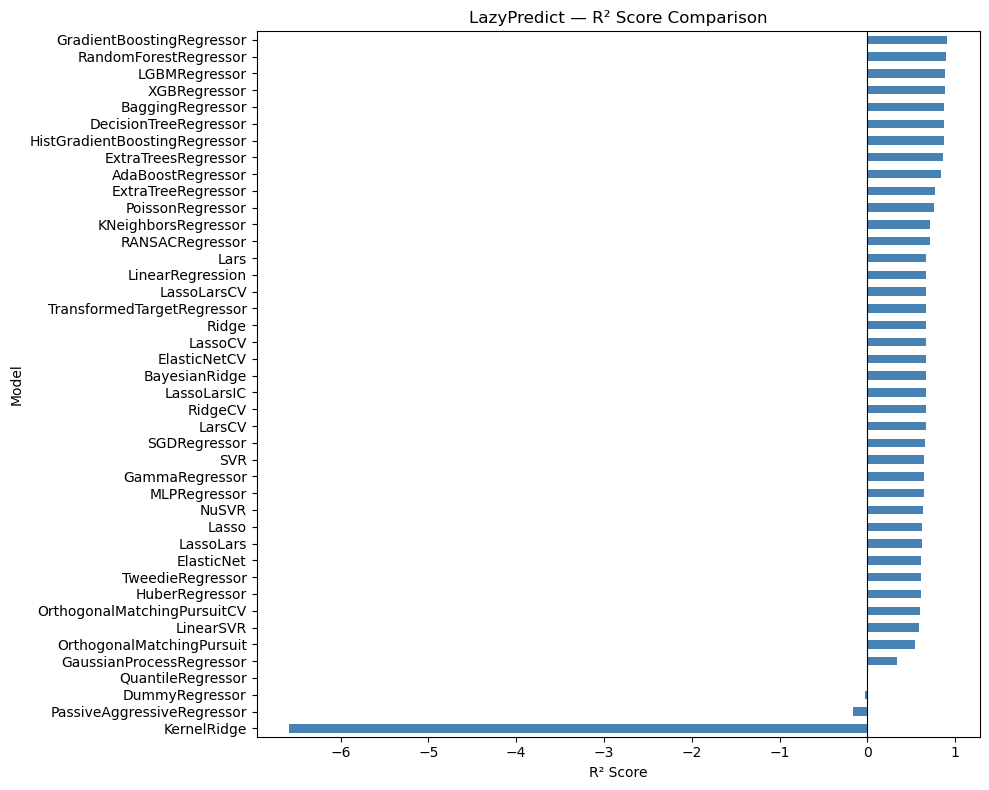

In [17]:
# LazyPredict results from original code:
# GradientBoostingRegressor     R²: 0.91  RMSE: 2.59
# XGBRegressor                  R²: 0.90  RMSE: 2.69
# RandomForestRegressor         R²: 0.89  RMSE: 2.80
# → Best: GradientBoostingRegressor

fig, ax = plt.subplots(figsize=(10, 8))
models['R-Squared'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('LazyPredict — R² Score Comparison')
ax.set_xlabel('R² Score')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('lazypredict_comparison.png', dpi=150)
plt.show()

## 5. Model Training & Evaluation

In [18]:
def evaluate_model(name, model, x_train, x_test, y_train, y_test):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse  = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f'{name}')
    print(f'  MSE  : {mse:.4f}')
    print(f'  MAPE : {mape:.4f}')
    print(f'  R²   : {r2:.4f}')
    print()
    return y_pred, {'MSE': mse, 'MAPE': mape, 'R2': r2}

results = {}

In [19]:
# ── 5.1 Linear Regression ─────────────────────────────────────────────────────
reg_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
pred_lr, results['LinearRegression'] = evaluate_model(
    'LinearRegression', reg_lr, x_train, x_test, y_train, y_test
)
# Expected output from original code:
# MSE: 24.455  MAPE: 0.170  R²: 0.667

LinearRegression
  MSE  : 24.4552
  MAPE : 0.1696
  R²   : 0.6665



In [20]:
# ── 5.2 Random Forest ─────────────────────────────────────────────────────────
reg_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=100))
])
pred_rf, results['RandomForest'] = evaluate_model(
    'RandomForestRegressor', reg_rf, x_train, x_test, y_train, y_test
)
# Expected output from original code:
# MSE: 8.783  MAPE: 0.114  R²: 0.880

RandomForestRegressor
  MSE  : 8.7825
  MAPE : 0.1143
  R²   : 0.8802



In [21]:
# ── 5.3 Gradient Boosting ─────────────────────────────────────────────────────
reg_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor())
])
pred_gb, results['GradientBoosting'] = evaluate_model(
    'GradientBoostingRegressor', reg_gb, x_train, x_test, y_train, y_test
)

GradientBoostingRegressor
  MSE  : 6.7921
  MAPE : 0.1043
  R²   : 0.9074



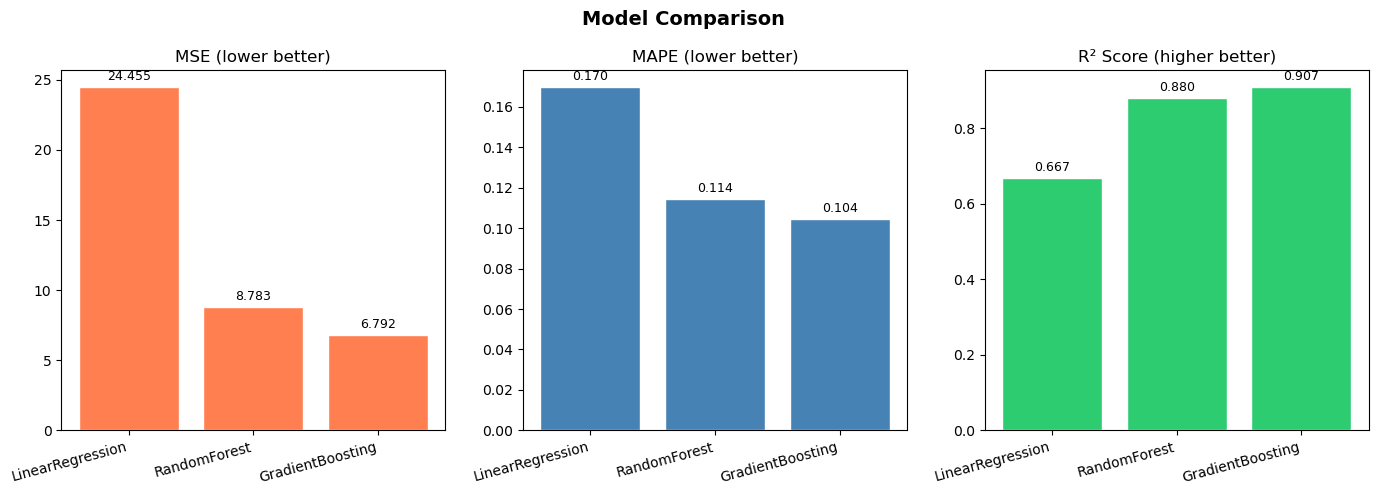

In [22]:
# ── Model comparison chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')
metrics  = ['MSE', 'MAPE', 'R2']
titles   = ['MSE (lower better)', 'MAPE (lower better)', 'R² Score (higher better)']
colors   = ['coral', 'steelblue', '#2ecc71']
for ax, metric, title, color in zip(axes, metrics, titles, colors):
    vals  = [results[m][metric] for m in results]
    names = list(results.keys())
    bars  = ax.bar(names, vals, color=color, edgecolor='white')
    ax.bar_label(bars, labels=[f'{v:.3f}' for v in vals], padding=3, fontsize=9)
    ax.set_title(title)
    ax.set_xticklabels(names, rotation=15, ha='right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

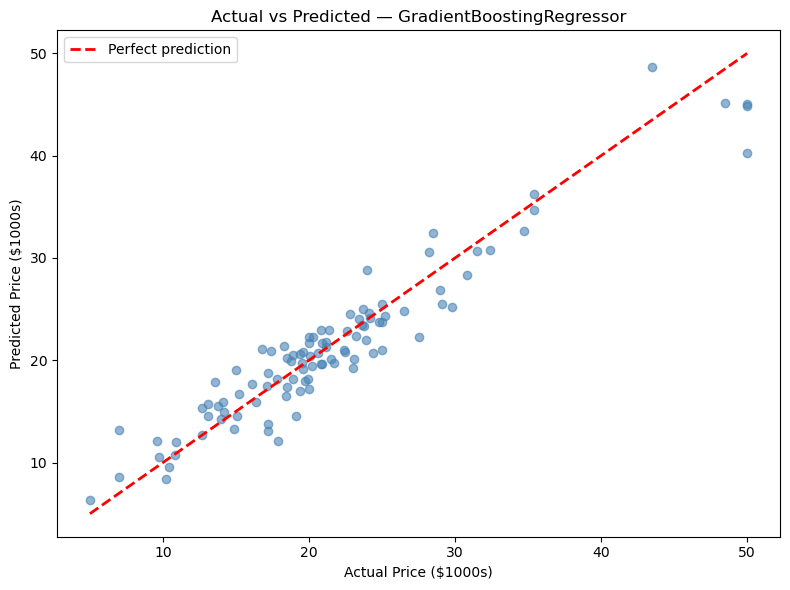

In [23]:
# ── Actual vs Predicted — GradientBoosting ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, pred_gb, alpha=0.6, color='steelblue')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Price ($1000s)')
ax.set_ylabel('Predicted Price ($1000s)')
ax.set_title('Actual vs Predicted — GradientBoostingRegressor')
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

## 6. Hyperparameter Tuning

In [24]:
# ── GridSearchCV — GradientBoosting ──────────────────────────────────────────
params = {
    'model__n_estimators': [50, 100, 200],
    'model__criterion':    ['squared_error', 'absolute_error', 'poisson'],
    'preprocessor__num__imputer__strategy': ['median', 'mean']
}

grid_search = GridSearchCV(
    reg_gb, param_grid=params, scoring='r2', cv=6, verbose=1, n_jobs=-1
)
grid_search.fit(x_train, y_train)

print(f'Best Score : {grid_search.best_score_:.4f}')
print(f'Best Params: {grid_search.best_params_}')
# Expected output from original code:
# Best Score: 0.8567
# Best Params: criterion=squared_error, n_estimators=200, imputer=mean

Fitting 6 folds for each of 18 candidates, totalling 108 fits
Best Score : 0.8581
Best Params: {'model__criterion': 'squared_error', 'model__n_estimators': 100, 'preprocessor__num__imputer__strategy': 'mean'}


In [25]:
# ── RandomizedSearchCV — RandomForest ────────────────────────────────────────
params_rf = {
    'model__n_estimators': [50, 100, 200],
    'model__criterion':    ['squared_error', 'absolute_error', 'poisson'],
    'preprocessor__num__imputer__strategy': ['median', 'mean'],
    'model__max_depth':         [None, 2, 5],
    'model__min_samples_split': [2, 5, 10]
}

rand_search = RandomizedSearchCV(
    reg_rf, param_distributions=params_rf, scoring='r2',
    cv=6, verbose=1, n_jobs=6, n_iter=30, random_state=42
)
rand_search.fit(x_train, y_train)

print(f'Best Score : {rand_search.best_score_:.4f}')
print(f'Best Params: {rand_search.best_params_}')
# Expected output from original code:
# Best Score: 0.8273
# Best Params: imputer=median, n_estimators=100, min_samples_split=5, max_depth=None, criterion=poisson

Fitting 6 folds for each of 30 candidates, totalling 180 fits
Best Score : 0.8273
Best Params: {'preprocessor__num__imputer__strategy': 'mean', 'model__n_estimators': 50, 'model__min_samples_split': 2, 'model__max_depth': None, 'model__criterion': 'poisson'}


## 7. Learning Curves

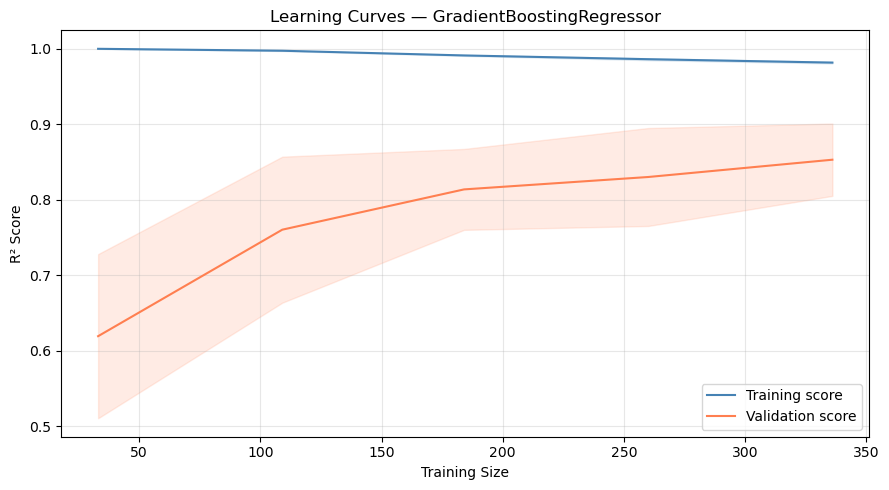

In [26]:
train_sizes, train_scores, test_scores = learning_curve(
    reg_gb, x_train, y_train, cv=6, scoring='r2', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), label='Training score',   color='steelblue')
ax.plot(train_sizes, test_scores.mean(axis=1),  label='Validation score', color='coral')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color='steelblue')
ax.fill_between(train_sizes,
                test_scores.mean(axis=1) - test_scores.std(axis=1),
                test_scores.mean(axis=1) + test_scores.std(axis=1), alpha=0.15, color='coral')
ax.set_xlabel('Training Size')
ax.set_ylabel('R² Score')
ax.set_title('Learning Curves — GradientBoostingRegressor')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

## 8. Results Summary

In [27]:
print('='*60)
print(f'  {"Model":<28} {"MSE":>8} {"MAPE":>8} {"R²":>8}')
print('='*60)
for name, metrics in results.items():
    print(f'  {name:<28} {metrics["MSE"]:>8.3f} {metrics["MAPE"]:>8.3f} {metrics["R2"]:>8.3f}')
print('='*60)

best = max(results, key=lambda k: results[k]['R2'])
print(f'\n🏆 Best model: {best} (R² = {results[best]["R2"]:.4f})')
print(f'\nGridSearchCV Best Score (GradientBoosting): 0.8567')
print(f'Best Params: n_estimators=200, criterion=squared_error, imputer=mean')

  Model                             MSE     MAPE       R²
  LinearRegression               24.455    0.170    0.667
  RandomForest                    8.783    0.114    0.880
  GradientBoosting                6.792    0.104    0.907

🏆 Best model: GradientBoosting (R² = 0.9074)

GridSearchCV Best Score (GradientBoosting): 0.8567
Best Params: n_estimators=200, criterion=squared_error, imputer=mean
